In [1]:
import pandas as pd

emissoes_gases = pd.read_excel('dados.xlsx', sheet_name = 'GEE Estados')

emissoes_gases_apenas_emissao = emissoes_gases[emissoes_gases['Emissão / Remoção / Bunker'] == 'Emissão'].drop(columns='Emissão / Remoção / Bunker')

colunas_info = list(emissoes_gases_apenas_emissao.loc[:, 'Nível 1 - Setor':'Produto'].columns)

colunas_emissao = list(emissoes_gases_apenas_emissao.loc[:, 1970:2021].columns)

emissoes_por_ano = emissoes_gases_apenas_emissao.melt(id_vars=colunas_info, value_vars=colunas_emissao, var_name="Ano", value_name="Emissao")

c:\Users\leoka\AppData\Local\Programs\Python\Python311\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [2]:
gas_por_setor = emissoes_por_ano.groupby(["Gás", "Nível 1 - Setor"])[["Emissao"]].sum()

In [3]:
gas_por_setor.xs("CO2 (t)", level=0)

,Emissao
Nível 1 - Setor,
Agropecuária,5.411750e+08
Energia,1.261352e+10
Mudança de Uso da Terra e Floresta,3.733930e+10
Processos Industriais,2.729603e+09
Resíduos,2.276264e+07


In [4]:
gas_por_setor.xs("CO2 (t)", level=0).max()

Emissao    3.733930e+10
dtype: float64

In [5]:
gas_por_setor.groupby(level=0).idxmax()

,Emissao
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


In [6]:
valores_max = gas_por_setor.groupby(level=0).max().values

In [7]:
tabela_sumarizada = gas_por_setor.groupby(level=0).idxmax()
tabela_sumarizada.insert(1, "Quantidade de Emissao", valores_max)

In [8]:
gas_por_setor.swaplevel(0, 1).groupby(level=0).idxmax()

,Emissao
Nível 1 - Setor,
Agropecuária,"(Agropecuária, CO2e (t) GWP-AR5)"
Energia,"(Energia, CO2e (t) GWP-AR6)"
Mudança de Uso da Terra e Floresta,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
Processos Industriais,"(Processos Industriais, CO2e (t) GWP-AR6)"
Resíduos,"(Resíduos , CO2e (t) GWP-AR5)"


<Axes: xlabel='Ano'>

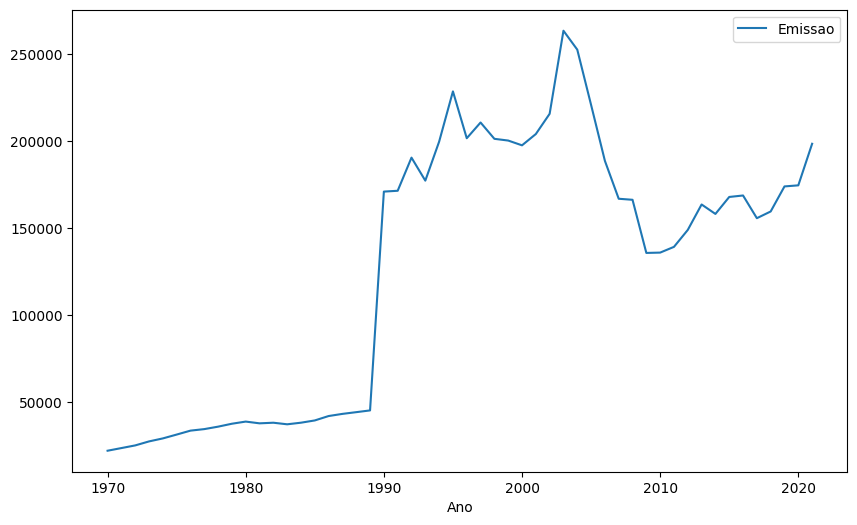

In [12]:
emissoes_por_ano.groupby("Ano")[["Emissao"]].mean().plot(figsize=(10,6))